In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from mamba_model import Mamba,MyCustomMamba, MambaConfig
import argparse
from DataProcessing import HankelMatrices
import scipy.io
import l4casadi as l4c
import casadi as cs

In [2]:
# Load multisine data from matlab
mat = scipy.io.loadmat("DataSets/u_dataChirpWhiteNoise.mat")
u_data = mat["u_data"]

mat = scipy.io.loadmat("DataSets/y_dataChirpWhiteNoise.mat")
y_data = mat["y_data"]

# convert data to tensors
u_data = np.array(u_data)
y_data = np.array(y_data)

u_data = torch.FloatTensor(u_data).transpose(0,1)
#u_data = u_data[0,:1000].unsqueeze(0).transpose(0,1)
y_data = torch.FloatTensor(y_data).transpose(0,1)
#y_data = y_data[0,:1000].unsqueeze(0).transpose(0,1)
#y_data = y_data[0,:].unsqueeze(1)
#torch.reshape(y_data,(1000, 1))
input_dim = list(u_data.shape)[1]
output_dim = list(y_data.shape)[1]

# Hyper parameters
T_ini = 5
T = y_data.shape[0]
N =10
DataShuffle = False
norm_data = True


u_data_train = u_data[0:round(0.8*T)]
y_data_train = y_data[0:round(0.8*T)]
U_ini, Y_ini,U_0_Nm1, Y_1_N = HankelMatrices(u_data_train,y_data_train,T_ini,N,round(0.8*T) , input_dim, output_dim )

trainX= torch.cat((U_ini, Y_ini, U_0_Nm1), 1)
trainy = Y_1_N


u_data_test = u_data
y_data_test = y_data
U_ini, Y_ini,U_0_Nm1, Y_1_N = HankelMatrices(u_data_test,y_data_test,T_ini,N,round(T) , input_dim, output_dim )

testX = torch.cat((U_ini, Y_ini, U_0_Nm1), 1)
testy = Y_1_N

Hankel Matrices Generated
Hankel Matrices Generated


In [3]:
class Net(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        self.config = MambaConfig(d_model=8, n_layers=1)
        self.lin1 = nn.Linear(in_dim,8)
        self.mamba = Mamba(self.config)
        self.lin2 = nn.Linear(8,out_dim)
        
    
    def forward(self,x):
        #print("Input Shape:"+str(x.shape))
        x = self.lin1(x.unsqueeze(0))
        x = self.mamba(x)
        x = self.lin2(x)
        return x.squeeze(0)
        

In [4]:
model = Net(19,10)
model.load_state_dict(torch.load("State_dicts/Test_model_Conv1E1"))
model.eval()


C:\Users\Michiel\AppData\Local\Temp\ipykernel_73328\1617569546.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("State_dicts/Test_model_C

Net(
  (lin1): Linear(in_features=19, out_features=8, bias=True)
  (mamba): Mamba(
    (layers): ModuleList(
      (0): ResidualBlock(
        (mixer): MambaBlock(
          (in_proj): Linear(in_features=8, out_features=16, bias=False)
          (conv1d): Conv1d(8, 8, kernel_size=(1,), stride=(1,), groups=8)
          (x_proj): Linear(in_features=8, out_features=17, bias=False)
          (dt_proj): Linear(in_features=1, out_features=8, bias=True)
          (out_proj): Linear(in_features=8, out_features=8, bias=False)
        )
        (norm): RMSNorm()
      )
    )
    (norm_f): RMSNorm()
  )
  (lin2): Linear(in_features=8, out_features=10, bias=True)
)

In [5]:
testX[1,:]

tensor([ -9.6369,  -3.7469,  -4.8193,  -7.5990,   1.2918,   1.2802,   1.2082,
          1.0520,   0.8460,  -4.4992,  -5.3255,  -0.0302,   1.2909,  -1.7271,
        -14.1156,  22.8052, -11.6023,  16.8585,  17.8700])

In [6]:
model.load_state_dict(torch.load("State_dicts/Test_model_Conv1E1"))
model.eval()
MambaModel = l4c.L4CasADi(model, device='cpu')
MambaModel(testX[1,:].unsqueeze(0))

C:\Users\Michiel\AppData\Local\Temp\ipykernel_73328\3928445713.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("State_dicts/Test_model_C

NotImplementedError: Wrong number or type of arguments for overloaded function 'Function_call'.
  Possible prototypes are:
    call(self,dict:DM,bool,bool)
    call(self,[DM],bool,bool)
    call(self,[SX],bool,bool)
    call(self,dict:SX,bool,bool)
    call(self,dict:MX,bool,bool)
    call(self,[MX],bool,bool)
  You have: '(Function,(Tensor))'


In [7]:
#Sampling Time
Ts = 0.1

# Simulation time
time_range =24

# Simulation steps
L = round(time_range/Ts)

# Init time
time = np.arange(L+1)*Ts

# Initial state
x1_init = 0
x2_init = 0

x1 = np.zeros(L + 1)
x2 = np.zeros(L + 1)
u = np.zeros(L)
ref = np.zeros(L)

#Choose the reference
f = 0.2  # Frequency in Hz
ref =  np.sin(2 * np.pi * f * time)

# Init arrays to initial state
x1[0] = x1_init
x2[0] = x2_init

#Maximum input
u_max = 15

#Model Variables
N = 10
Tini =5

#Controller Variables
Q = 100
R =  0.5
Rd = 0
S = 100

#Casadi variables 
u = cs.MX.sym('u', N) 
y = cs.MX.sym('y', N)
ref = cs.MX.sym('ref', N)
u_init = cs.MX.sym('u_init') 
u_ini = cs.MX.sym('u_ini', Tini-1) 
y_ini = cs.MX.sym('y_ini', Tini)
# input = cs.vertcat(u_ini, y_ini,u)
inputs = cs.MX.sym('inputs', 19)
model_output = cs.MX.sym('model_output',10)
# gvar = cs.SX.sym('gvar', length(u_data)-N)
model = Net(19,10)
model.load_state_dict(torch.load("State_dicts/Test_model_Conv1E1"))
model.eval()
MambaModel = l4c.L4CasADi(model, device='cpu')


# Define cost function (example: quadratic tracking)
cost = 0
cost += (u[1]- u_init)*Rd*(u[1]- u_init)  # Control effort
cost +=  u[N-1]*R*u[N-1]
cost +=  (y[N-1] - ref[N-1])*S*(y[N-1] - ref[N-1])
for i in range(N-1):
    cost += (y[i] - ref[i])*Q*(y[i] - ref[i])  # Tracking error

for i in range(N-2):
    cost += (u[i+1]- u[i])*Rd*(u[i+1]- u[i])  # Control effort
    cost +=  u[i]*R*u[i]
# Create a CasADi function for the cost
f_cost = cs.Function('f_cost', [u, y, ref,u_init], [cost]) 

# Model Constraint
constraint1 =  MambaModel(inputs.T).T-y

# Define lower and upper bounds for the box constraint
lower_bound = -u_max  # Example lower bound
upper_bound = u_max  # Example upper boun

constraint2 = u <= upper_bound  # Upper bound constraint
constraint3 = u >= lower_bound  # Lower bound constraint
constraint4 = inputs- cs.vertcat(u_ini, y_ini,u)

# Create a CasADi function for the constraint
f_constraint = cs.Function('f_constraint', [u], [constraint1]) 

# Example usage within an optimization problem:
# ... (Your optimization problem setup) ...
nlp_prob = {'x': u, 'f': f_cost, 'g': f_constraint} 

# Define the solver parameters
opts = {}
opts['ipopt.print_level'] = 0  # Set to 0 for less output

# Create the NLP solver
solver = cs.nlpsol('solver', 'ipopt', nlp_prob, opts)


# Initial guess for the optimization variable (replace with your initial guess)
u0 = 1

# Solve the optimization problem
sol = solver(x0=u0)

# Extract the solution
x_opt = sol['x'] 

print("Optimal solution:", x_opt)


# # ---------- SIMULATION ----------

# for idx in range(1):

#     # ---------- SIMULATE USER INPUT ----------
#     if idx == 0:
#         y_ini = np.concatenate((y_ini[1:], [x1[idx]])) 
#         u_ini = u_ini 

#     elif idx >= 1:
#         y_ini = np.concatenate((y_ini[1:], [x1[idx]])) 
#         u_ini = np.concatenate((u_ini[1:], [uvec[idx-1]])) 
    
#     # Increment time
#     time += Ts

#     # ---------- CONTROL SYSTEM LOOP ----------


C:\Users\Michiel\AppData\Local\Temp\ipykernel_73328\1628341689.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("State_dicts/Test_model_

Exception: Compilation failed!

Attempted to execute OS command:
cmake -S _l4c_generated -B _l4c_generated -DCMAKE_RULE_MESSAGES=OFF && cmake --build _l4c_generated --config=Release&&  cmake --install _l4c_generated --config=Release



C:\Users\Michiel\AppData\Local\Temp\ipykernel_1560\3994357899.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("State_dicts/Test_model_Co

torch.Size([1986, 10])


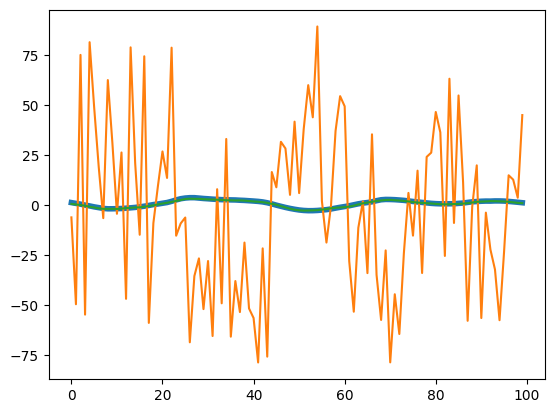

In [ ]:
model.load_state_dict(torch.load("State_dicts/Test_model_Conv1E1"))
model.eval()
mx_inp = cs.MX.sym('x', 19, 1)
l4c_model = l4c.realtime.RealTimeL4CasADi(model, approximation_order=2)

casadi_lin_approx_sym_out= l4c_model(mx_inp)
casadi_lin_approx_func = cs.Function('model2_lin',
                                        [mx_inp,
                                        l4c_model.get_sym_params()],
                                        [casadi_lin_approx_sym_out])
casadi_lin_approx_param = l4c_model .get_params(np.zeros((19,)))

# Evaluate the functions and compare to the torch MLP
inputs = testX[:1000,:]
torch_out = model(inputs).detach().numpy()
casadi_lin_out = []
casadi_quad_out = []

# Casadi can not handle batches
for i in range(len(inputs)):
    casadi_lin_out.append(casadi_lin_approx_func(inputs[i,:].detach().numpy(), casadi_lin_approx_param))

casadi_lin_out = np.array(casadi_lin_out).squeeze(axis=-1)
print(testy.shape)

plt.plot(torch_out[:100,1], label='Torch', linewidth=4)
plt.plot(casadi_lin_out[:100,1], label='RealTimeL4CasADi Quadratic')
plt.plot(testy[:100,1], label='RealTimeL4CasADi Quadratic')